In [1]:
import numpy as np         
import os                  
import random 
import matplotlib.pyplot as plt
 
import cv2
TRAIN_DIR = 'C:/Users/Raj/Desktop/New folder/training_set/training_set'
TEST_DIR = 'C:/Users/Raj/Desktop/New folder/test_set/test_set'


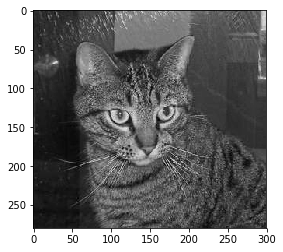

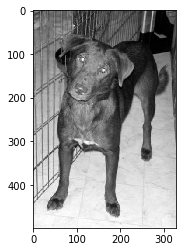

In [2]:
datadir='C:/Users/Raj/Desktop/New folder/training_set/training_set'
category=['cats','dogs']
for i in category:
    path=os.path.join(datadir,i)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
     

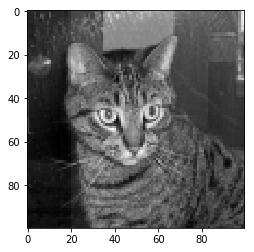

In [3]:
IMG_SIZE=100
new_array=cv2.resize(img_array,(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA)
plt.imshow(new_array,cmap='gray')
plt.show()

In [4]:
training_data=[]
def create_training_data():
    for i in category:
        path=os.path.join(TRAIN_DIR,i)
        class_num=category.index(i)
        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_AREA)
                training_data.append([new_array,class_num])
            except Exception as e:
                pass
create_training_data()


In [5]:
training_data

[[array([[ 43,  44,  50, ..., 115, 184, 195],
         [ 40,  38,  42, ..., 117, 175, 193],
         [ 43,  37,  38, ..., 110, 178, 195],
         ...,
         [ 21,  20,  20, ...,  65,  73,  51],
         [ 24,  19,  21, ...,  50,  45,  35],
         [ 28,  20,  23, ...,  68,  36,  37]], dtype=uint8), 0],
 [array([[ 34,  30,  45, ..., 152, 153, 149],
         [ 48,  51,  54, ..., 152, 155, 152],
         [ 55,  56,  57, ..., 154, 157, 154],
         ...,
         [159, 155, 153, ..., 169, 172, 158],
         [166, 158, 152, ..., 168, 171, 156],
         [146, 136, 134, ..., 169, 170, 153]], dtype=uint8), 0],
 [array([[221, 223, 222, ..., 242, 240, 243],
         [222, 222, 223, ..., 246, 241, 238],
         [222, 222, 220, ..., 249, 244, 243],
         ...,
         [206, 201, 193, ..., 215, 212, 214],
         [210, 209, 203, ..., 215, 212, 213],
         [214, 207, 191, ..., 216, 212, 213]], dtype=uint8), 0],
 [array([[115, 118, 122, ...,  60,  90,  68],
         [ 99, 105, 111, ..

In [6]:
len(training_data)

8005

In [7]:
import random
random.shuffle(training_data)

In [8]:
for sample in training_data[:10]:
    print(sample[1])

0
1
0
1
1
0
1
1
1
0


In [9]:
testing_data=[]
def create_testing_data():
    for i in category:
        path=os.path.join(TEST_DIR,i)
        class_num=category.index(i)
        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_AREA)
                testing_data.append([new_array,class_num])
            except Exception as e:
                pass
create_testing_data()

In [10]:
testing_data

[[array([[ 53,  94,  70, ...,  82,  78,  41],
         [ 69, 206, 129, ..., 181, 150,  44],
         [ 67, 228, 133, ..., 186, 167,  36],
         ...,
         [ 68, 187, 118, ..., 193, 171,  41],
         [ 68, 135,  89, ..., 139, 129,  40],
         [ 28,  32,  19, ...,  29,  30,  19]], dtype=uint8), 0],
 [array([[116, 116, 112, ...,  58,  58,  56],
         [116, 118, 120, ...,  60,  57,  57],
         [112, 124, 122, ...,  58,  62,  72],
         ...,
         [ 77,  78,  79, ...,  55,  55,  56],
         [ 77,  79,  80, ...,  56,  55,  56],
         [ 77,  76,  78, ...,  56,  56,  55]], dtype=uint8), 0],
 [array([[ 56,  58,  59, ...,  84,  87,  84],
         [ 54,  48,  64, ...,  88,  88,  87],
         [ 45,  52,  67, ...,  86,  84,  85],
         ...,
         [138, 157, 155, ..., 135, 127, 129],
         [137, 142, 149, ..., 138, 143, 144],
         [133, 131, 142, ..., 134, 140, 142]], dtype=uint8), 0],
 [array([[ 92,  91,  99, ..., 105, 106,  96],
         [ 88,  98,  98, ..

In [11]:
len(testing_data)

2023

In [12]:
import random
random.shuffle(testing_data)

In [13]:
for sample in testing_data[:10]:
    print(sample[1])

0
1
1
1
1
1
1
1
1
0


In [14]:
X=[]
y=[]

In [15]:
for features,label in training_data:
    X.append(features)
    y.append(label)

In [16]:
len(X)

8005

In [17]:
X=np.array(X).reshape(-1,IMG_SIZE,IMG_SIZE,1)
X.shape

(8005, 100, 100, 1)

In [18]:
X.shape[1:]

(100, 100, 1)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten,Conv2D,MaxPooling2D

C:\Users\Raj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Raj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Raj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\Raj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:519: FutureWarning: Passing (type

In [20]:
model=Sequential()
model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(100))
model.add(Activation('sigmoid'))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


In [21]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
X=X/255.0

In [23]:
X

array([[[[0.49019608],
         [0.49411765],
         [0.49803922],
         ...,
         [0.30980392],
         [0.30980392],
         [0.29019608]],

        [[0.50980392],
         [0.49803922],
         [0.50588235],
         ...,
         [0.32156863],
         [0.32156863],
         [0.29803922]],

        [[0.54117647],
         [0.50980392],
         [0.50980392],
         ...,
         [0.31372549],
         [0.31764706],
         [0.30980392]],

        ...,

        [[0.45490196],
         [0.45882353],
         [0.45490196],
         ...,
         [0.2745098 ],
         [0.2627451 ],
         [0.25490196]],

        [[0.45098039],
         [0.45098039],
         [0.45098039],
         ...,
         [0.26666667],
         [0.25098039],
         [0.25098039]],

        [[0.43921569],
         [0.44705882],
         [0.44705882],
         ...,
         [0.25882353],
         [0.24313725],
         [0.23529412]]],


       [[[0.16862745],
         [0.17254902],
         [0.17

In [24]:
y=np.array(y,dtype=np.uint8)
y

array([1, 0, 1, ..., 1, 1, 1], dtype=uint8)

In [ ]:
model.fit(X,y,validation_split=0.3,epochs=10)

Train on 5603 samples, validate on 2402 samples
Epoch 1/10
5603/5603 [==============================] - 345s 62ms/sample - loss: 0.6901 - acc: 0.5265 - val_loss: 0.6769 - val_acc: 0.5895
Epoch 2/10
3424/5603 [=================>............] - ETA: 1:40 - loss: 0.6733 - acc: 0.5859

In [26]:
def prepare(filepath):
    img_size=100
    img_array=cv2.imread(filepath,cv2.IMREAD_GRAYSCALE)
    new_array=cv2.resize(img_array,(img_size,img_size),interpolation=cv2.INTER_AREA)
    return np.array(new_array).reshape(-1,img_size,img_size,1)

In [27]:
a=prepare('meow.jpg')
a=a/255
a

array([[[[0.16470588],
         [0.19215686],
         [0.17647059],
         ...,
         [0.34509804],
         [0.4745098 ],
         [0.75294118]],

        [[0.16078431],
         [0.16078431],
         [0.18039216],
         ...,
         [0.36862745],
         [0.45882353],
         [0.74901961]],

        [[0.15686275],
         [0.14901961],
         [0.19607843],
         ...,
         [0.36862745],
         [0.46666667],
         [0.75294118]],

        ...,

        [[0.09411765],
         [0.08627451],
         [0.09019608],
         ...,
         [0.25490196],
         [0.25098039],
         [0.23921569]],

        [[0.07843137],
         [0.08235294],
         [0.08627451],
         ...,
         [0.16862745],
         [0.22352941],
         [0.24313725]],

        [[0.09411765],
         [0.08627451],
         [0.08627451],
         ...,
         [0.25882353],
         [0.23137255],
         [0.14117647]]]])

In [28]:
pred=model.predict([a])
pred

array([[0.74714077]], dtype=float32)

In [29]:
model.predict_classes([a])

array([[1]])

In [30]:
b=prepare('dog.jpg')
b=b/255.0
b

array([[[[0.42745098],
         [0.40392157],
         [0.39607843],
         ...,
         [0.69019608],
         [0.6627451 ],
         [0.63137255]],

        [[0.43529412],
         [0.40784314],
         [0.4       ],
         ...,
         [0.61568627],
         [0.59607843],
         [0.57647059]],

        [[0.43137255],
         [0.40784314],
         [0.39607843],
         ...,
         [0.56862745],
         [0.56078431],
         [0.55686275]],

        ...,

        [[0.42745098],
         [0.42745098],
         [0.42352941],
         ...,
         [0.61960784],
         [0.61568627],
         [0.62352941]],

        [[0.43137255],
         [0.42745098],
         [0.42745098],
         ...,
         [0.63137255],
         [0.61568627],
         [0.61568627]],

        [[0.42352941],
         [0.42745098],
         [0.43137255],
         ...,
         [0.62745098],
         [0.61568627],
         [0.61568627]]]])

In [32]:
model.predict([b])

array([[0.5840381]], dtype=float32)

In [33]:
model.predict_classes([b])

array([[1]])

In [34]:
len(testing_data)

2023

In [35]:
x1=[]
y1=[]

In [36]:
for features,label in testing_data:
    x1.append(features)
    y1.append(label)

In [37]:
x1=np.array(x1).reshape(-1,IMG_SIZE,IMG_SIZE,1)
x1

array([[[[ 95],
         [ 84],
         [ 85],
         ...,
         [ 39],
         [ 39],
         [ 39]],

        [[ 99],
         [ 89],
         [ 92],
         ...,
         [ 37],
         [ 38],
         [ 40]],

        [[103],
         [ 98],
         [ 99],
         ...,
         [ 37],
         [ 39],
         [ 37]],

        ...,

        [[181],
         [170],
         [173],
         ...,
         [151],
         [149],
         [152]],

        [[177],
         [174],
         [173],
         ...,
         [151],
         [147],
         [152]],

        [[180],
         [180],
         [182],
         ...,
         [152],
         [151],
         [148]]],


       [[[148],
         [155],
         [141],
         ...,
         [201],
         [201],
         [200]],

        [[123],
         [142],
         [130],
         ...,
         [202],
         [204],
         [201]],

        [[127],
         [137],
         [182],
         ...,
         [207],
         [

In [38]:
y1=np.array(y1,dtype=np.uint8)
y1

array([1, 0, 0, ..., 1, 1, 1], dtype=uint8)

In [39]:
x1=x1/255.0

In [40]:
model.predict_classes(x1)

array([[1],
       [0],
       [1],
       ...,
       [1],
       [0],
       [1]])

In [41]:
y1[:5]

array([1, 0, 0, 1, 1], dtype=uint8)

In [42]:
model.predict_classes(x1[:5])

array([[1],
       [0],
       [1],
       [1],
       [1]])